            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


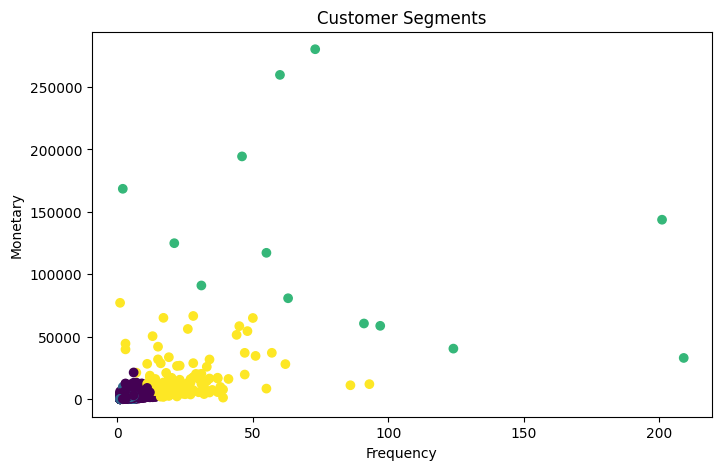

In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ===============================
# LOAD CLEANED DATA
# ===============================
df = pd.read_csv("cleaned_retail.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# ===============================
# CREATE RFM TABLE
# ===============================

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(rfm.head())

# ===============================
# SCALING
# ===============================
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# ===============================
# KMEANS CLUSTERING
# ===============================
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm.head())

# ===============================
# VISUALIZATION
# ===============================
plt.figure(figsize=(8,5))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segments")
plt.show()
